# Housing Cost Burden and Economic Vulnerability in California
County-level analysis using Census ACS, HUD Fair Market Rents, and BLS LAUS data (2012-2023)

In [11]:
import sys
import os

# notebook lives in root, src/ is one level down
sys.path.insert(0, 'src')

# override data and results paths to work from root
os.chdir(os.path.dirname(os.path.abspath('results.ipynb')))

import pandas as pd
from IPython.display import Image

from config import DATA_DIR, RESULTS_DIR, CLUSTERED_FILE
from analyze import (plot_cluster_summary, plot_counties_by_tier,
                     plot_tier_over_time, plot_california_map,
                     get_tier_summary, get_counties_by_tier)

# patch paths for notebook context
DATA_DIR = "data"
RESULTS_DIR = "results"
CLUSTERED_FILE = "ca_housing_clustered.csv"

## Step 1: Load the clustered dataset
Run main.py first to generate this file.

In [12]:
# load the already-processed and clustered data saved by main.py
df = pd.read_csv(os.path.join(DATA_DIR, CLUSTERED_FILE))
print(df.shape)
df.head()

(693, 9)


,fips2010,county_name,median_gross_rent,renter_burden_count,year,fmr_2br,unemployment_rate,cluster,policy_tier
0,604799999,Merced,832,9081,2012,789.0,16.4,0,high unemployment burden
1,604399999,Mariposa,797,330,2012,831.0,12.3,0,high unemployment burden
2,611599999,Yuba,870,2119,2012,857.0,15.4,0,high unemployment burden
3,601399999,Contra Costa,1340,33316,2012,1402.0,9.0,2,low burden
4,603599999,Lassen,873,1036,2012,887.0,12.5,0,high unemployment burden


## Step 2: Summary statistics by policy tier

In [13]:
summary = get_tier_summary(df)
print(summary)

                          median_gross_rent  fmr_2br  unemployment_rate
policy_tier                                                            
high rent burden                    2204.75  2831.31               4.17
high unemployment burden             913.89   892.59              13.40
low burden                          1061.66  1042.27               7.04
moderate rent burden                1605.47  1728.13               5.29


## Step 3: County tier assignments (2023)

In [14]:
counties_2023 = get_counties_by_tier(df, year=2023)
print(f"Total counties in 2023: {len(counties_2023)}")
print()
for tier in ["high rent burden", "moderate rent burden", "low burden", "high unemployment burden"]:
    group = counties_2023[counties_2023["policy_tier"] == tier]["county_name"].tolist()
    print(f"{tier} ({len(group)} counties):")
    print(", ".join(sorted(group)))
    print()

Total counties in 2023: 57

high rent burden (14 counties):
Alameda, Contra Costa, Marin, Monterey, Napa, Orange, San Diego, San Francisco, San Mateo, Santa Barbara, Santa Clara, Santa Cruz, Sonoma, Ventura

moderate rent burden (15 counties):
Calaveras, El Dorado, Los Angeles, Mono, Nevada, Placer, Riverside, Sacramento, San Benito, San Bernardino, San Joaquin, San Luis Obispo, Solano, Stanislaus, Yolo

low burden (26 counties):
Amador, Butte, Del Norte, Fresno, Glenn, Humboldt, Inyo, Kern, Kings, Lake, Lassen, Madera, Mariposa, Mendocino, Merced, Modoc, Plumas, Shasta, Sierra, Siskiyou, Sutter, Tehama, Trinity, Tulare, Tuolumne, Yuba

high unemployment burden (2 counties):
Colusa, Imperial



## Step 4: Visualizations

Saved cluster summary chart to ../results/cluster_summary.png


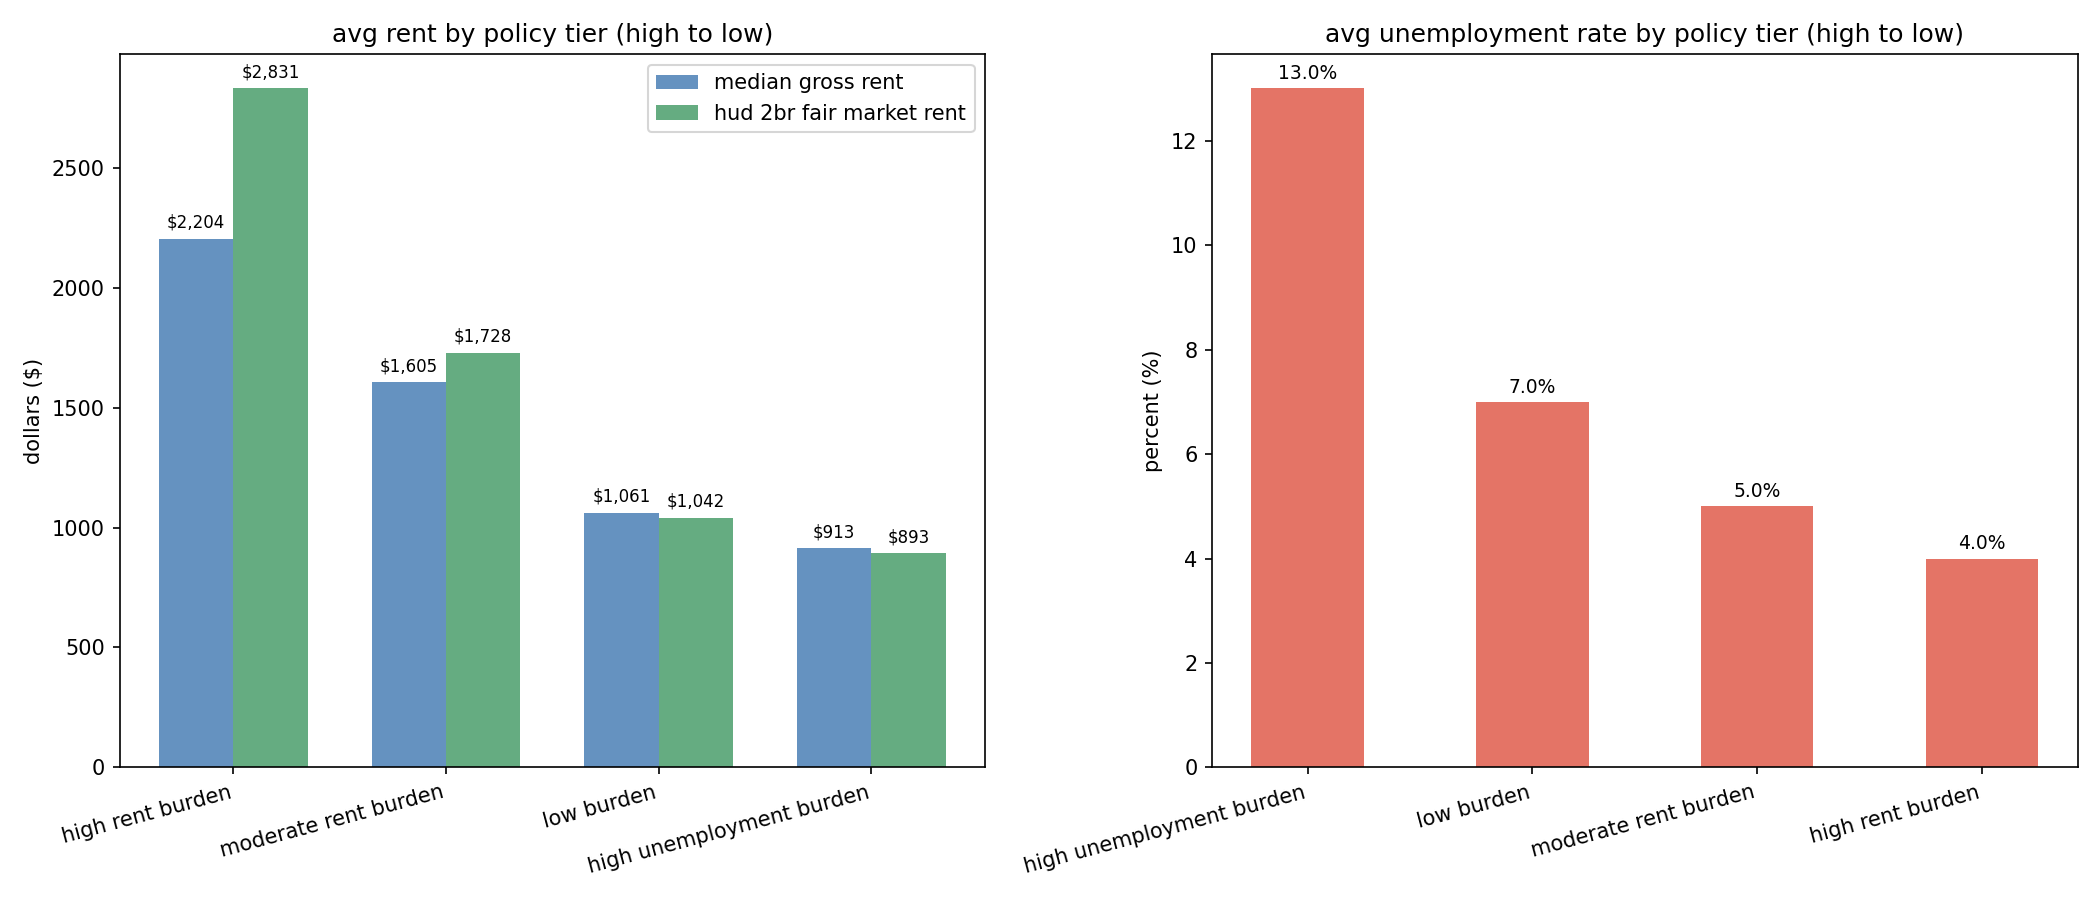

In [15]:
plot_cluster_summary(df)
Image(os.path.join(RESULTS_DIR, 'cluster_summary.png'))

Saved county scatter plot to ../results/counties_by_tier_2023.png


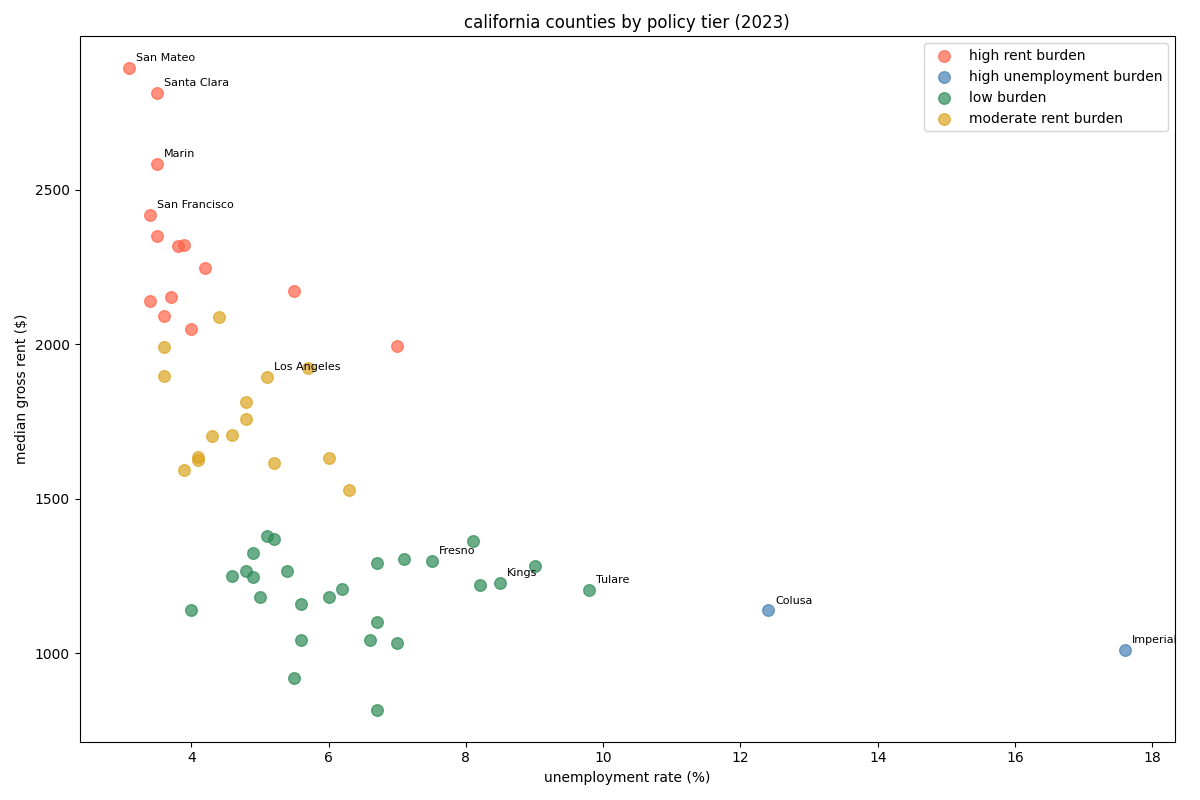

In [16]:
plot_counties_by_tier(df)
Image(os.path.join(RESULTS_DIR, 'counties_by_tier_2023.png'))

Saved tier over time chart to ../results/tier_over_time.png


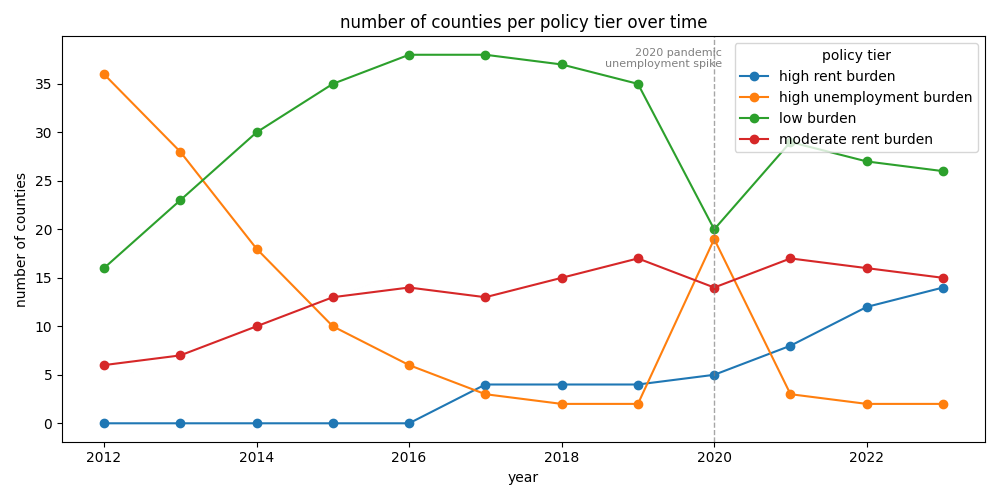

In [17]:
plot_tier_over_time(df)
Image(os.path.join(RESULTS_DIR, 'tier_over_time.png'))

Saved california map to ../results/ca_map_2023.png


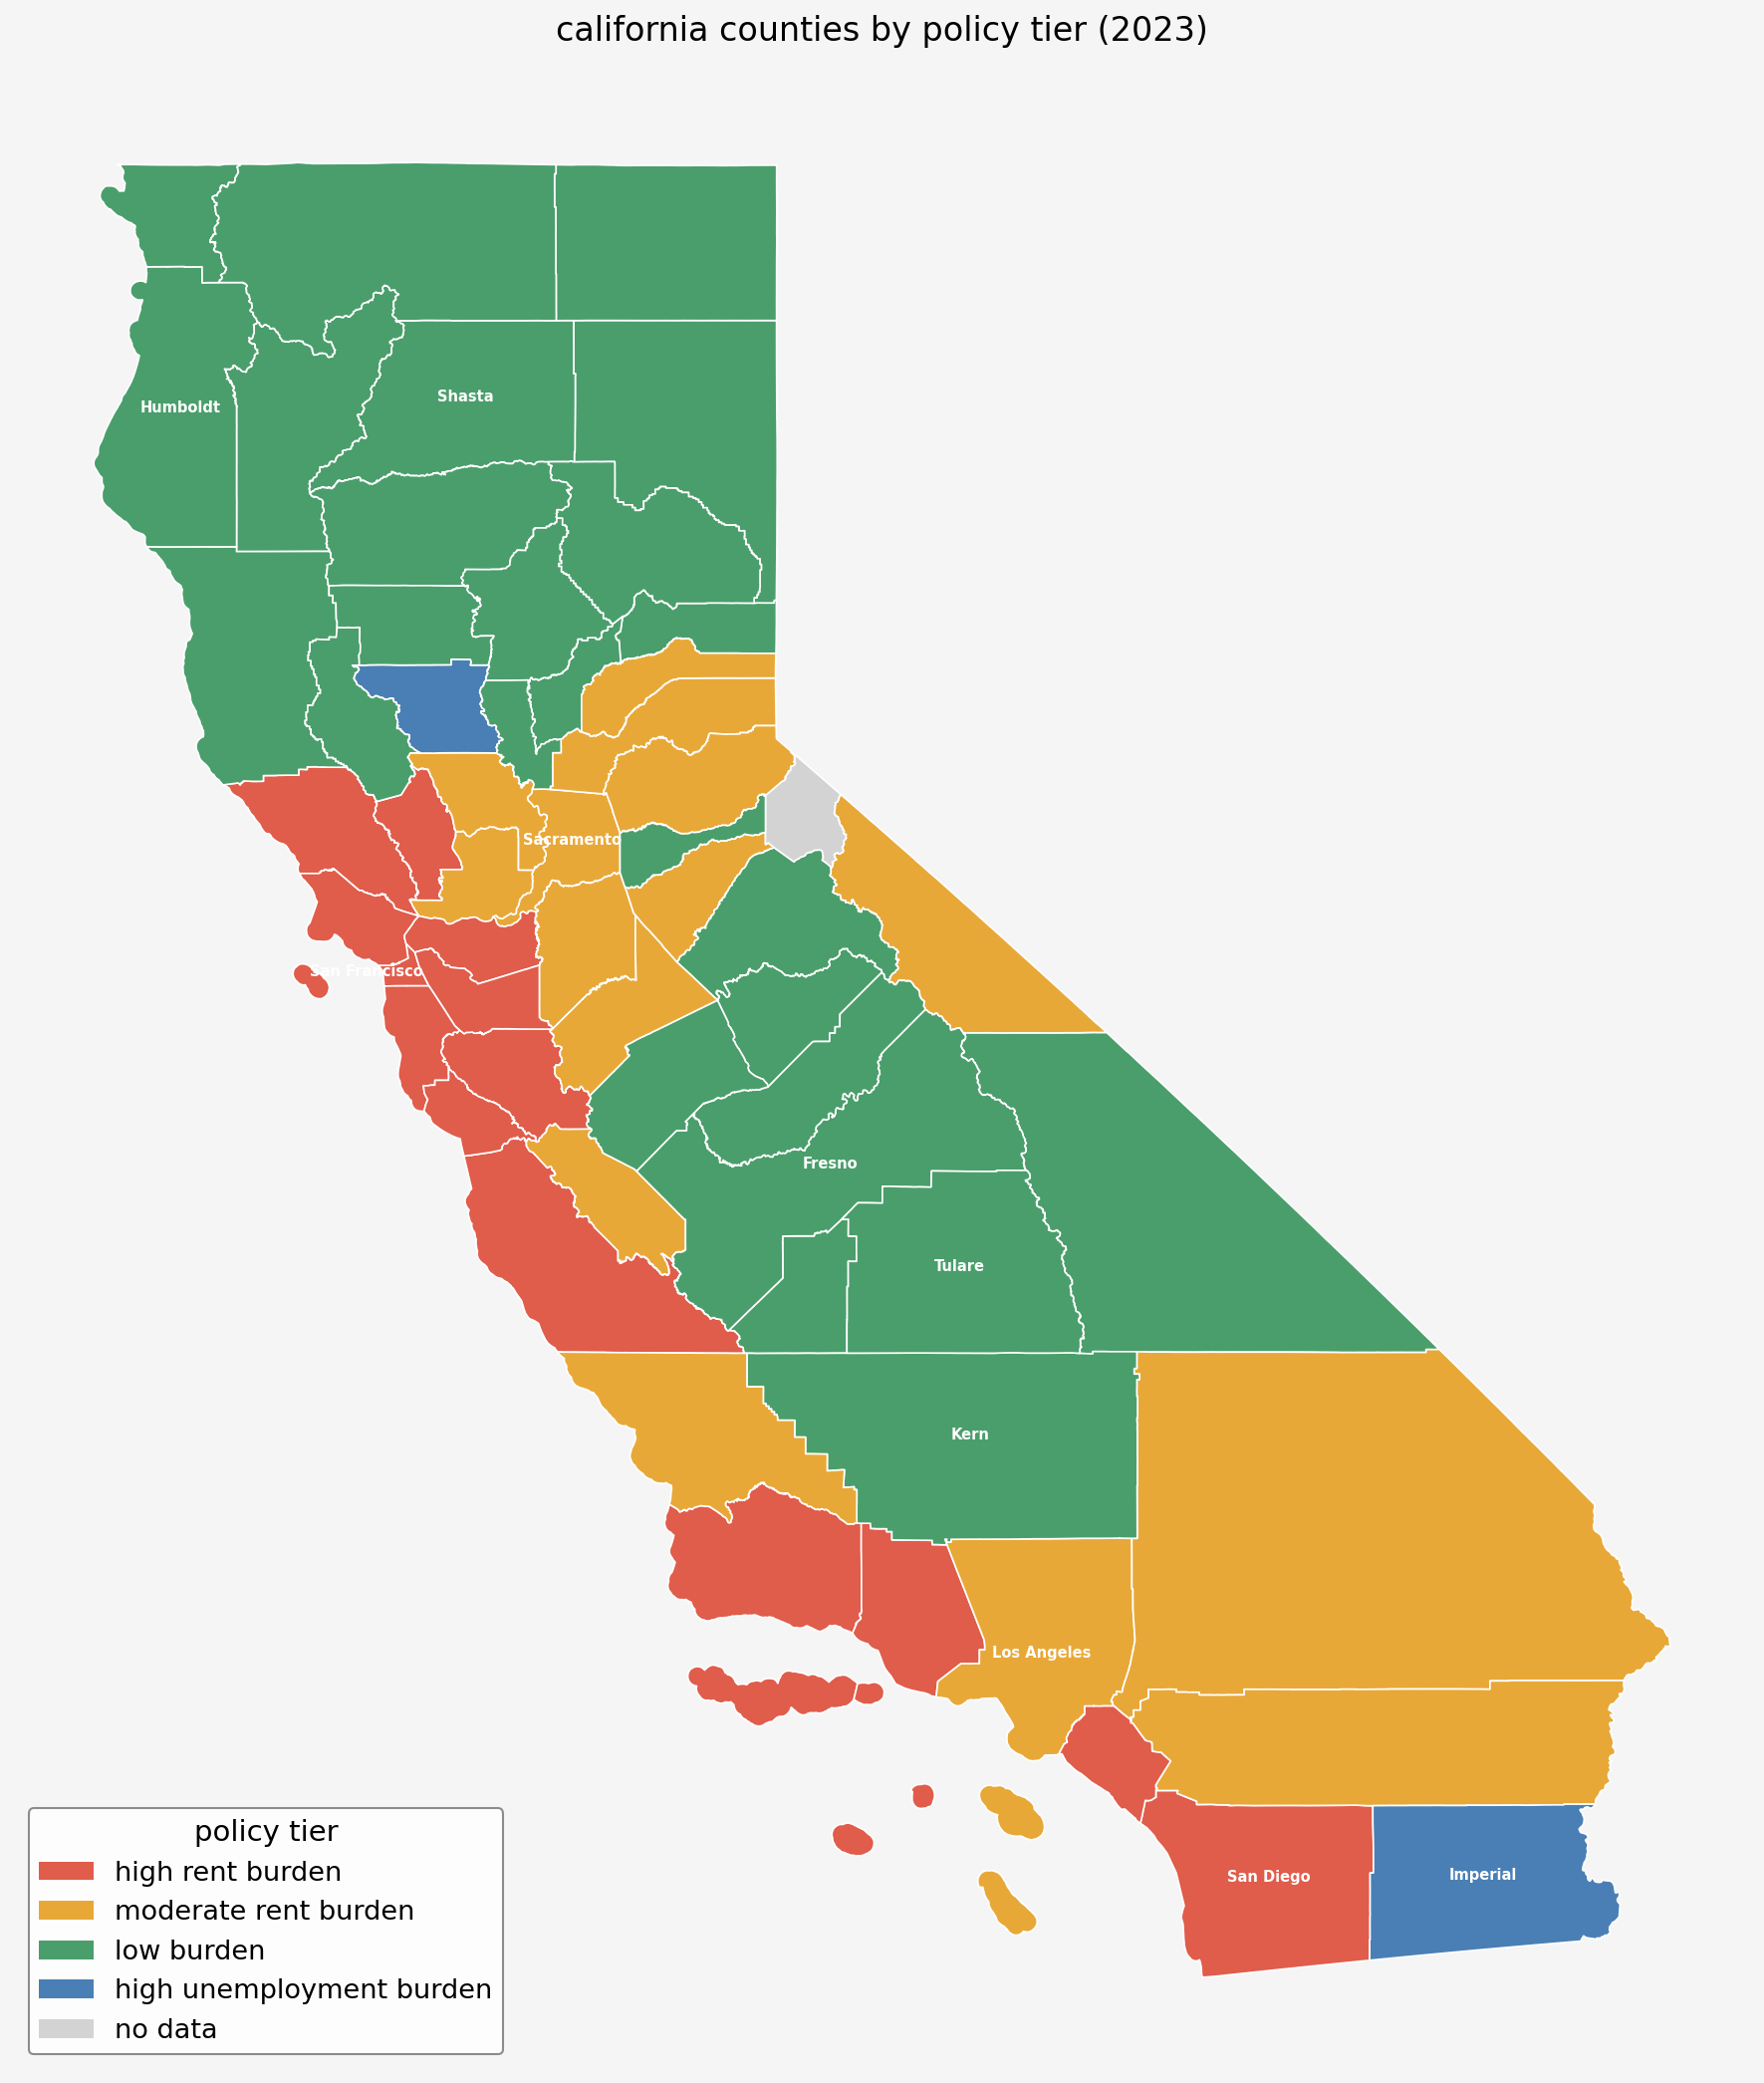

In [18]:
plot_california_map(df)
Image(os.path.join(RESULTS_DIR, 'ca_map_2023.png'))